# Students at Risk: Mental Health & Burnout

This is machine Learning Algortim

In [11]:
import pandas as pd

In [17]:
import pandas as pd

# 1. Last inn data
df = pd.read_csv('student_mental_health_burnout_1M.csv')

# 2. Sjekk n x d formatet (Krav i punkt 43)
print(f"Datasettets dimensjoner (n x d): {df.shape}")

# 3. Sjekk for manglende verdier (Krav i punkt 46 og 73)
print("\nManglende verdier per kolonne:")
print(df.isna().sum())

# 4. Sjekk klassebalanse (Krav i punkt 70a)
# Dette er kritisk å ha med i rapporten din!
print("\nKlassefordeling (risk_level):")
print(df['risk_level'].value_counts(normalize=True) * 100)

# 5. Statistikk i et mer lesbart format (Krav i punkt 72)
# .T (transpose) gjør det ofte lettere å lese når du har mange kolonner
stats = df.describe().T
print("\nStatistisk oversikt (Mean, Median, Q1, Q3 osv.):")
print(stats)

# 6. Ta et tilfeldig utvalg for resten av kodingen (Anbefalt for hastighet)
# Siden du skal kjøre kNN og K-means i dag, vil 1 million rader ta for lang tid.
df_sample = df.sample(n=50000, random_state=42)
print(f"\nBruker et utvalg på {df_sample.shape[0]} rader for videre analyse.")

Datasettets dimensjoner (n x d): (1000000, 20)

Manglende verdier per kolonne:
age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64

Klassefordeling (risk_level):
risk_level
Low       76.6645
Medium    21.8275
High       1.5080
Name: proportion, dtype: float64

Statistisk oversikt (Mean, Median, Q1, Q3 osv.):
                          count       mean       std        min        25%  \
age                   1000000.0  22.996456  3.742579  17.000000  20.000000   
academic_year         1000000.0   2.500782  1.117749 

Duplicates found: 0
                           Mean     Median       Mode   Std Dev   Variance  \
age                   23.012260  23.000000       20.0  3.735322  13.952629   
academic_year          2.501520   3.000000        4.0  1.120082   1.254583   
study_hours_per_day    5.013562   5.013920        0.0  1.981346   3.925732   
exam_pressure          6.008875   6.015213       10.0  1.545556   2.388745   
academic_performance  71.041004  71.030736  47.246335  5.642324  31.835815   
stress_level           4.255597   4.255530        0.0  1.675860   2.808506   
anxiety_score          2.999632   2.978128        0.0  1.513105   2.289487   
depression_score       1.275325   1.048710        0.0  1.218341   1.484355   
sleep_hours            6.505493   6.500727       10.0  1.475286   2.176469   
physical_activity      3.008363   2.994164        0.0  1.467358   2.153141   
social_support         4.992785   4.987985        0.0  1.974774   3.899731   
screen_time            5.021047   5.000181  

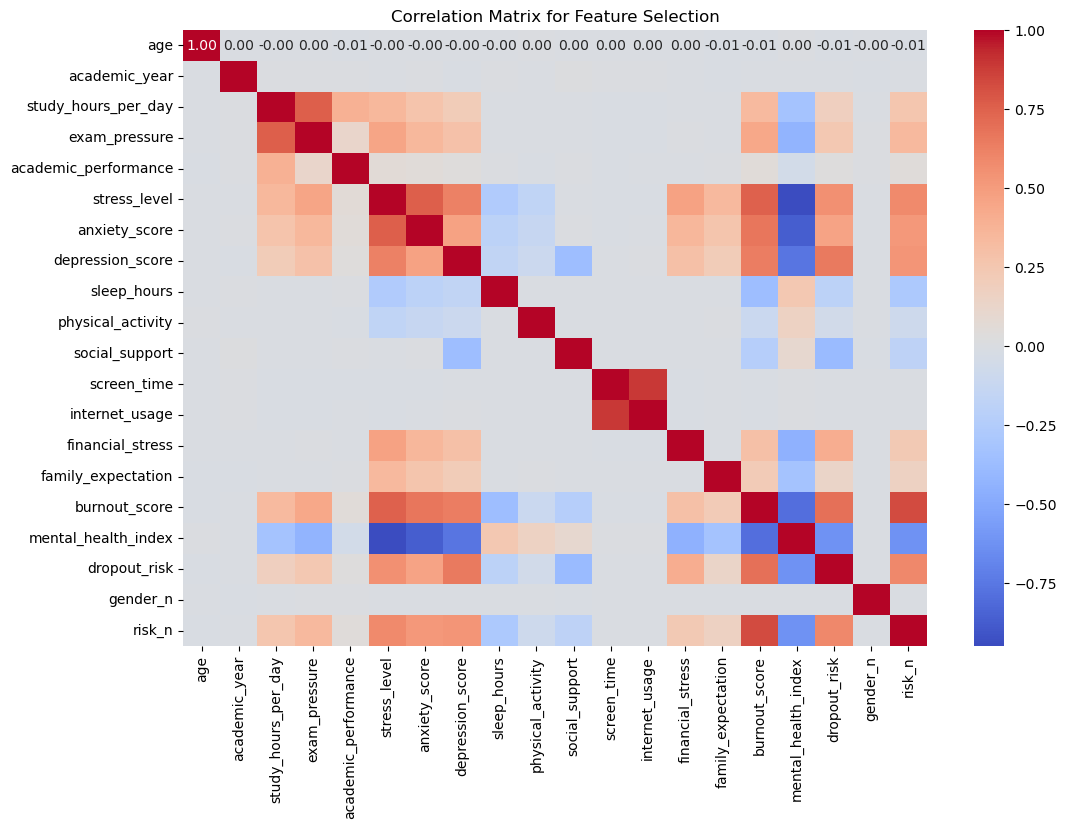

C:\Users\abdul\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


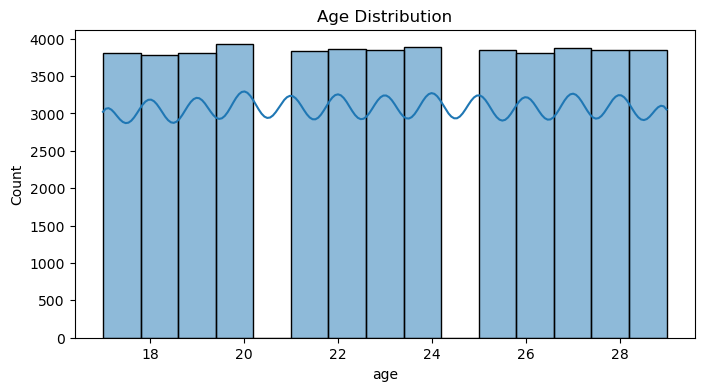

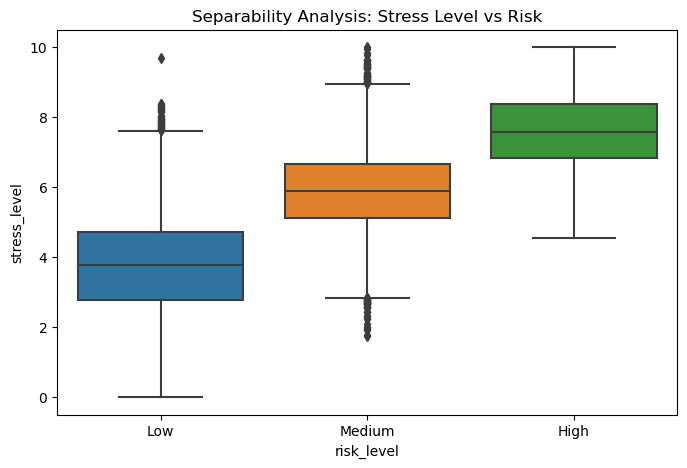

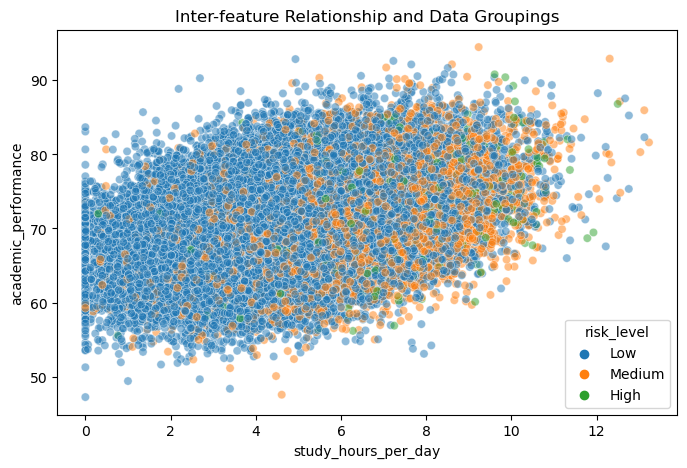

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND SAMPLE DATA [cite: 42-43]
# Ensure the filename matches your actual file
df = pd.read_csv('student_mental_health_burnout_1M.csv')
# Sampling 50,000 rows for efficiency in O(N^2) calculations [cite: 122]
df_sample = df.sample(n=50000, random_state=42).copy()

# 2. HANDLE MISSING, DUPLICATES, AND OUTLIERS [cite: 46, 73-74]
print(f"Duplicates found: {df_sample.duplicated().sum()}")
df_sample = df_sample.drop_duplicates()
df_sample = df_sample.dropna() # Handles missing values if any

# 3. CONVERT QUALITATIVE/CATEGORICAL DATA [cite: 45, 73]
# Mandatory step: transform text values into numerical values
df_sample['gender_n'] = df_sample['gender'].map({'Male': 0, 'Female': 1})
df_sample['risk_n'] = df_sample['risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# 4. CALCULATE STATISTICS [cite: 72]
# Required: mean, mode, median, standard variance, Q1 and Q3
stats = df_sample.describe().T
stats['mode'] = df_sample.mode().iloc[0]
stats['variance'] = df_sample.var(numeric_only=True)
# Rename columns for the report table
stats_clean = stats[['mean', '50%', 'mode', 'std', 'variance', '25%', '75%']]
stats_clean.columns = ['Mean', 'Median', 'Mode', 'Std Dev', 'Variance', 'Q1', 'Q3']
print(stats_clean)

# 5. FEATURE SELECTION AND CORRELATION [cite: 47-49]
plt.figure(figsize=(12, 8))
sns.heatmap(df_sample.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix for Feature Selection")
plt.show() # Look for features strongly related to target or each other

# 6. VISUAL ANALYSIS (EDA) [cite: 44, 68]
# Histogram: Distribution of Age [cite: 68]
plt.figure(figsize=(8, 4))
sns.histplot(df_sample['age'], kde=True, bins=15)
plt.title('Age Distribution')
plt.show()

# Boxplot: Separability of stress_level by risk_level [cite: 68, 77]
plt.figure(figsize=(8, 5))
sns.boxplot(x='risk_level', y='stress_level', data=df_sample)
plt.title('Separability Analysis: Stress Level vs Risk')
plt.show()

# Scatter Plot: Relationship between Study Hours and Performance [cite: 68, 71]
plt.figure(figsize=(8, 5))
sns.scatterplot(x='study_hours_per_day', y='academic_performance', hue='risk_level', data=df_sample, alpha=0.5)
plt.title('Inter-feature Relationship and Data Groupings')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. KLARGJØRING AV DATA
# Vi velger ut features og target basert på analysen din
features = ['age', 'academic_year', 'study_hours_per_day', 'exam_pressure',
            'academic_performance', 'stress_level', 'sleep_hours', 'burnout_score']

# Bruker utvalget på 50,000 rader for hastighet
X = df_sample[features]
# Vi må konvertere risk_level til tall manuelt hvis det ikke er gjort
y = df_sample['risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# 2. DELING I TRENING OG TEST (80% trening, 20% test) [cite: 82, 97]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Trening: {len(X_train)} (80%), Test: {len(X_test)} (20%)")

# --- ALGORITME 1: DECISION TREE [cite: 81] ---
print("\n--- Eksperimenter: Decision Tree ---")
depths = [3, 10, 20] # 3 eksperimenter med ulik dybde [cite: 83]

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"Max Depth {d}: Accuracy = {acc:.4f}")

# --- ALGORITME 2: k-NEAREST NEIGHBORS (kNN) [cite: 81] ---
print("\n--- Eksperimenter: kNN ---")
neighbors = [3, 11, 51] # 3 eksperimenter med ulikt antall naboer [cite: 83]

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"k={k}: Accuracy = {acc:.4f}")

# EKSEMPEL PÅ DETALJERT EVALUERING (for det siste eksperimentet) [cite: 86]
print("\nDetaljert rapport for siste kNN-modell:")
print(classification_report(y_test, preds, target_names=['Low', 'Medium', 'High']))

Trening: 40000 (80%), Test: 10000 (20%)

--- Eksperimenter: Decision Tree ---
Max Depth 3: Accuracy = 0.9999
Max Depth 10: Accuracy = 0.9999
Max Depth 20: Accuracy = 0.9999

--- Eksperimenter: kNN ---
k=3: Accuracy = 0.9340
k=11: Accuracy = 0.9386
k=51: Accuracy = 0.9312

Detaljert rapport for siste kNN-modell:
              precision    recall  f1-score   support

         Low       0.94      0.99      0.97      7617
      Medium       0.89      0.79      0.84      2211
        High       1.00      0.12      0.22       172

    accuracy                           0.93     10000
   macro avg       0.94      0.63      0.67     10000
weighted avg       0.93      0.93      0.92     10000



--- Eksperimenter: K-Means ---
K=2 | Silhouette Score: 0.1923
K=3 | Silhouette Score: 0.1393
K=4 | Silhouette Score: 0.1264
K=5 | Silhouette Score: 0.1249
K=6 | Silhouette Score: 0.1233

--- Eksperimenter: DBSCAN ---
eps=0.5, min_samples=5 | Antall klynger funnet: 0
eps=1.0, min_samples=5 | Antall klynger funnet: 46
eps=1.0, min_samples=10 | Antall klynger funnet: 13


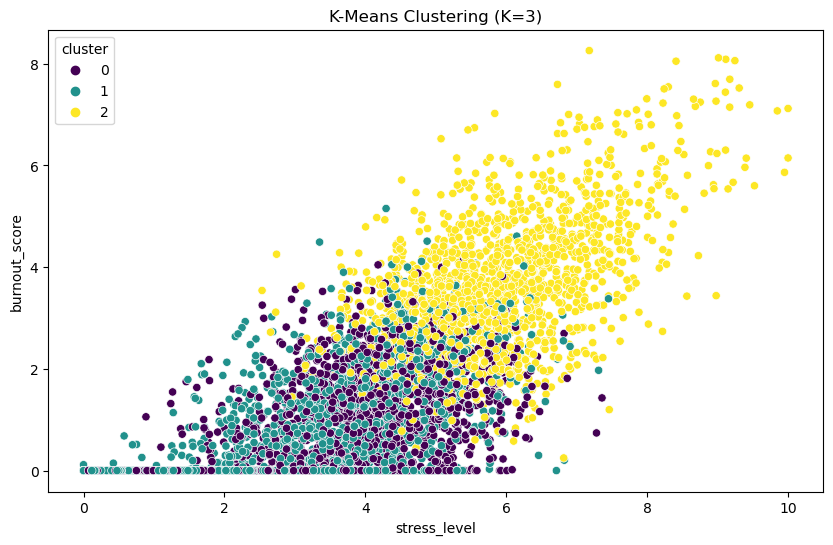

In [19]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. KLARGJØRING (Uveiledet læring bruker ikke fasit/y) [cite: 101]
# Vi bruker et mindre utvalg (5000) for Silhouette Score pga tidsbruk
X_unsupervised = X.sample(n=5000, random_state=42)

# Viktig: Klynging krever ofte skalering av data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

# --- EKSPERIMENT 1: K-MEANS (5 ulike k-verdier)  ---
print("--- Eksperimenter: K-Means ---")
k_values = [2, 3, 4, 5, 6]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} | Silhouette Score: {score:.4f}")

# --- EKSPERIMENT 2: DBSCAN (3 eksperimenter) [cite: 106] ---
print("\n--- Eksperimenter: DBSCAN ---")
# Vi endrer 'eps' (maks avstand mellom punkter) og 'min_samples'
dbscan_params = [(0.5, 5), (1.0, 5), (1.0, 10)]

for eps, min_s in dbscan_params:
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps}, min_samples={min_s} | Antall klynger funnet: {n_clusters}")

# VISUALISERING AV KLYNGER (Velg beste K-Means) [cite: 107, 116]
best_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_unsupervised['cluster'] = best_kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='stress_level', y='burnout_score', hue='cluster', data=X_unsupervised, palette='viridis')
plt.title("K-Means Clustering (K=3)")
plt.show()